In [6]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import trange

In [32]:
# An helper method for generating integers in a given range (for connection weights)
def random_int_gen(low=-2, high=5, size=None):
    return np.random.randint(low, high, size=size)

# A class for connected neural clusters
class NeuralCluster(): #reusable object - cluster of connected neurons
    def __init__(self, N:int, density): 
        # Size of the network
        self.N = N
        # Weights of the connection : sparse matrix of density d
        w_base = 10* np.diag(random_int_gen(size=N-1),k=1) #each neuron connects to next
        w_base[-1,0] = 10* random_int_gen() #connects last neuron back to first 
        self.w = w_base + sp.sparse.random_array((N,N), density = density, data_sampler=random_int_gen) #add extra random sparse connections
        
        
        # initialize the array that will hold the firing rates (size 1xN)
        self.v = np.empty((1,N))
        self.I = np.zeros(N)
    
    # Set the external input. Positive values = excitation
    def set_input(self, I):
        self.I = I

    # Initialize the cluster at x0 (size N), for n_steps time steps of dt s (total duration: n_steps*dt)
    def init_dynamics(self, x0, n_steps:int, dt):
        self.n_steps = n_steps
        self.dt = dt
        self.T = dt * n_steps

        self.v = np.empty((n_steps, self.N)) #voltage over time
        self.spike_trains = np.zeros((n_steps, self.N ))
        self.spike_count = np.zeros (n_steps)
        
        # This will hold the flow at time t
        self.flow = np.zeros((n_steps, self.N))
        self.v[0] = x0 #initial 

        #LIF parameters
        self.v_threshold = 0.5
        self.v_reset = 0
        
        # Time scale
        self.t = dt * np.arange(n_steps)
        
        #store spike trains and counts
        self.spike_trains = np.zeros((n_steps, self.N))
        self.spike_count = np.zeros(n_steps)

    # At a given time step, compute the flow of the cluster F(x) = -x + f(wx+I)
    #flow = -current activity + sigmoid(weighted input + external input)

    def compute_flow(self, idx:int, I=0):
        self.flow[idx] = -self.v[idx] + self.w @ self.spike_trains[idx] + self.I + I

    #At a given time step, compute the dynamics using Euler's method: x(t+dt) = x(t) + dt * F(x(t))
    def compute_dynamics_step(self, idx:int):
        self.compute_flow(idx)

        # update voltage
        self.v[idx+1] = self.v[idx] + self.dt * self.flow[idx] #update voltage

        # check which neurons spike
        spiked = self.v[idx+1] >= self.v_threshold #boolean array, which neuron spiked

        # store spikes
        self.spike_trains[idx+1] = spiked.astype(float) #matrix, which neuron spiked

        # count spikes at this time step
        self.spike_count[idx+1] = np.sum(spiked) #sum how many neurons spiked at each time step

        # reset neurons that spiked
        self.v[idx+1, spiked] = self.v_reset #reset those that spiked

    # Compute the full dynamics from initial condition x0 (size N), total duration T, time step dt
    def compute_dynamics(self, x0, T, dt):
        n_steps = int(T/dt)
        self.init_dynamics(x0, n_steps, dt)
        
        for idx in trange(n_steps - 1, desc="Computing dynamics steps"):
            self.compute_dynamics_step(idx)
        
    
        self.compute_spike_count()

    def compute_spike_count(self):
        self.spike_count = np.sum(self.spike_trains, axis=1)


    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spike_trains[:,i]
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)
    


# Helper method to plot the dynamics (one color for the whole cluster)
def plot_dynamics(cluster, color):
    t = cluster.t
    v = cluster.v
    for i in range(cluster.N):
        plt.plot(t, v[:, i], c=color)

In [33]:
# A class to implement the whole network : two conencted cluseters, linked by inhibitory basket cells. 
class ConnectedClusters(NeuralCluster): #connected cluster takes from neural cluster
    def __init__(self, N1, N2, n_baskets):
        self.N1 = N1
        self.N2 = N2
        self.n_baskets = n_baskets
        # Cluster 1
        self.cluster1 = NeuralCluster(N1, 0.1)
        # Cluster 2
        self.cluster2 = NeuralCluster(N2, 0.1)
        # Basket cell affectation array: to each neuron in cluster1/2 correspond one basket cell. Size 2xN.
        self.basket_affectation = np.concatenate([np.random.randint(0, n_baskets, size=N1), #assign each neuron tp basket cell
                                                  np.random.randint(0, n_baskets, size=N2)])
        
        super().__init__(N1 + N2 + n_baskets, 0)
        self.w = np.empty((N1 + N2 + n_baskets, N1 + N2 + n_baskets)) #weight matrix for all network
        for i in range(N1):
            b = np.zeros(n_baskets) #vector for basket cell connections
            b[self.basket_affectation[i]] = -50 #inhibitory connection
            self.w[i] = np.concatenate([self.cluster1.w[i], np.zeros(N2), b])
        for i in range(N2):
            b = np.zeros(n_baskets)
            b[self.basket_affectation[N1+i]] = -50
            self.w[N1+i] = np.concatenate([np.zeros(N1), self.cluster2.w[i], b])
        for i in range(n_baskets):
            self.w[N1+N2+i] = np.concatenate([np.where(self.basket_affectation==i, 10, 0),
                                            np.zeros(n_baskets)])

    def compute_dynamics(self, x0, T, dt):
        super().compute_dynamics(x0, T, dt)
        self.cluster1.v = self.v[:, :self.N1]
        print(self.cluster1.v.shape)
        self.cluster2.v = self.v[:, self.N1:self.N1 + self.N2]
        print(self.cluster2.v.shape)
        self.cluster1.t = self.t
        self.cluster2.t = self.t
        self.cluster1.spike_trains = self.spike_trains[:, :self.N1]
        self.cluster2.spike_trains = self.spike_trains[:, self.N1:self.N1 + self.N2]
        self.cluster1.compute_spike_count()
        self.cluster2.compute_spike_count()
    
    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spike_trains[:,i]
            event.append(np.nonzero(st)[0])
        colors=np.concatenate([np.full(self.N1, 'k'), np.full(self.N2, 'b'), np.full(self.n_baskets, 'r')])
        plt.eventplot(event, colors=colors, zorder = 0)

In [38]:
N1 = 40
N2 = 40
n_baskets = 20

model = ConnectedClusters(N1, N2, n_baskets)
I = 30 * np.concatenate([np.ones(N1), np.zeros(N2 + n_baskets)])
model.set_input(I)
x0 = np.concatenate([np.random.rand(N1 + N2), np.zeros(n_baskets)])
model.compute_dynamics(x0, 20, 0.001)

Computing dynamics steps: 100%|██████████| 19999/19999 [00:00<00:00, 117302.39it/s]

(20000, 40)
(20000, 40)


In [39]:
print("Total spikes:", np.sum(model.spike_trains))
print("Max voltage:", np.max(model.v))

Total spikes: 47811.0
Max voltage: 0.9939066823098976


In [40]:
print("Cluster 1 spikes:", np.sum(model.spike_trains[:, :model.N1]))
print("Cluster 2 spikes:", np.sum(model.spike_trains[:, model.N1:model.N1 + model.N2]))
print("Basket spikes:", np.sum(model.spike_trains[:, model.N1 + model.N2:]))

Cluster 1 spikes: 47037.0
Cluster 2 spikes: 25.0
Basket spikes: 749.0


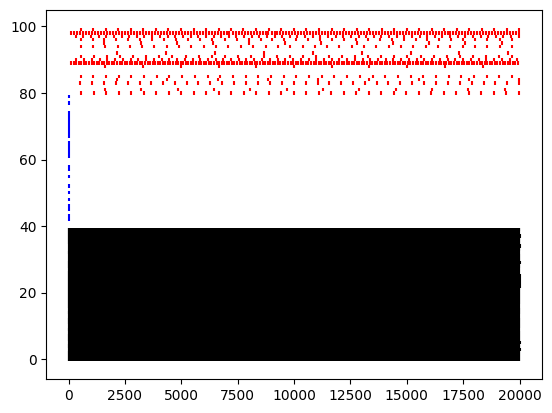

In [41]:
model.plot_raster()